<a href="https://colab.research.google.com/github/r-okotie179/projectTantalus/blob/main/synthetic_disease_outbreak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I have a (quite old) interest in epidemiology and I feel that it will be better to use synthetic data to model this relationship between edges: it will cause me to consider how to encode probabilities and equations against nodes.

### Inspiration

I intend to write a piece on either/both Foot and Mouth Disease (FMD) and Mad Cow Disease. The introductory part of this video would explore modelling attempts for a newly emerging disease and the importance of decisions (which then progresses to how these predictions affect policy and the downstream political responses to farmer's responses to mass culling as a preventative measure).

Reading through all the technical sources has done nothing for me and so constructing a vague approximation for what will happen is a much better approach.

Then the model can be refined with increasing complexity (and would allow me to reach out to Christyl Donnelly or other researchers and their testimonials on both the maths and their downstream effects).

Thus, below is the model.

# Model I
Inspired by the distribution of farmlands and their connection networks. The disease I will work towards is BSE (less variables) and see how the sharing of food-stock (and how the use of animal meal can transfer between farms), as well as the delayed emergence of symptoms and what response would be best suited for this.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

### Research & AI
Used `Claude Sonnet 5 Extra Thinking` to know roughly what the median value of cattle there were in the UK; I assumed it would follow an exponential distribution (where a small amount of farms would have large cattle sizes, but probably less centralised food sources; it would contain very high amounts of shared transportation and shared food sources).

**Improvements**: Distribution with the below equation now presents more apparently the larger, more infrequent farming clusters:

```
f = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)
```

/tmp/ipykernel_484/3310671864.py:7: RuntimeWarning: divide by zero encountered in divide
  f = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)


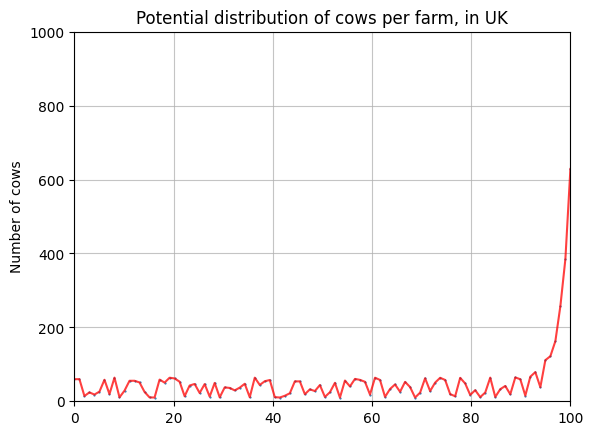

In [2]:
# distribution of number of cattle
## it can and will be improved with other distributions
## I will sample uniformly from f

x = np.linspace(0, 100, 100)
a = 37 # median
f = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)

plt.xlim(0, 100)
plt.ylim(0, 1000)
plt.scatter(x, f, s=.3)
plt.plot(x, f, color='r', alpha=.75)
plt.title("Potential distribution of cows per farm, in UK")
plt.ylabel("Number of cows")
plt.grid(alpha=0.75)
plt.show()

#print(f)

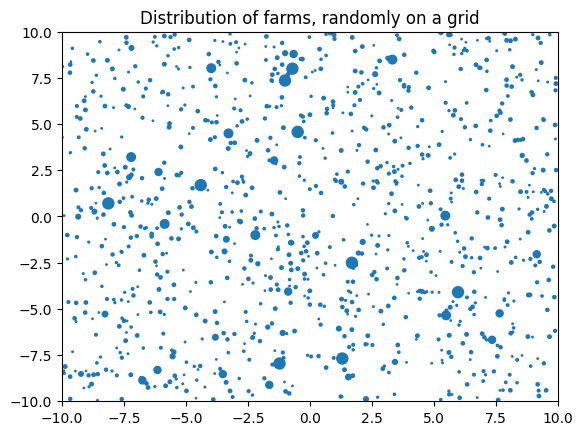

In [3]:
u = 10 # size of gridding

def farmland(n): # output n nodes
  farmlands = []
  for each_farm in range(n):
    # num cattle, position, centrality (1 indicates entire food source is shared and eaten from one big piece, 0 implies each individual sheep has its own feeding  )
    nc = np.random.choice(f).astype(int)
    position = (np.random.uniform(-u,u), np.random.uniform(-u,u))
    farmlands.append([nc,position])
  df_farms = pd.DataFrame(farmlands, columns=['Cattle No.', 'Position'])
  return df_farms # as dataframe

test = farmland(1000)
pos = np.array(test['Position'].tolist())

plt.scatter(pos[:,0], pos[:,1], s=np.array(test['Cattle No.'])/u)
plt.xlim(-u,u)
plt.ylim(-u,u)
plt.title("Distribution of farms, randomly on a grid")
plt.show()

## Connections of each graph
A directed graph is one in which the magnitude of the edge weight going from nodes A -> B is not necessarily the same as B -> A.

I want to represent the farms like this since large farms would be (**in my head, based off of nothing**) more likely to be the focal point of distribution networks.

I want the connections between farms to be a function of their proximity and size and iterate this over all farms (a wholly inefficient algorithm).

The first step of this is to have a function for the probability of an edge occuring in one direction between two nodes:

$$\text{Let u} =\frac{x_{n} \text{dist}(x_{p}, y_{p})}{y_{n}}$$

Where $x_n$ is the number of cattle on a given farm, $x_p$ is its position and the function $\text{dist}(x,y)$ computes the distance between two coordinate values.

$$P(x_i, x_j) = f(u)$$

The $\frac{x_n}{y_n}$ term encodes that *size matters* and then larger farms would be more likely to send resources to smaller farms (likely in some assimilation attempt to grow). This was inspired by the idea of equilibrium. If $x_n << y_n$ it reduces the overall chance of an edge occuring in that direction.

The distance between the nodes is trivial.

For $f(x)$, I would like a function that can compress positive, real inputs to outputs between 0 and 1.

I will print out some potential functions that has this quality and try to understand why some are used over others.

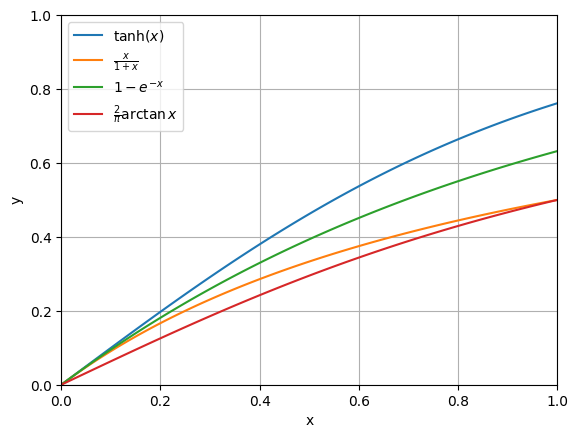

In [ ]:
'''
f(x) contenders:
tanhx, 2(arctanx)/pi, 1-e^-x, x/(1+x)
I used Claude to get this list, although it's quite standard
'''
z = np.linspace(0, 1, 100)
tanh = (np.exp(2 * z) - 1)/(np.exp(2 * z) + 1)
polyn = z/(1+z)
arctan = (2/np.pi) * np.arctan(z)
exp = 1 - np.exp(-z)

plt.plot(z, tanh, label=r'$\tanh(x)$')
plt.plot(z, polyn, label=r'$\frac{x}{1+x}$')
plt.plot(z, exp, label=r'$1-e^{-x}$')
plt.plot(z, arctan, label=r'$\frac{2}{\pi}\arctan{x}$')


plt.ylim(0,1)
plt.xlim(0,1)
#plt.axis('equal')

plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.legend()
plt.show()

Since this range is much smaller than what my input would be (is my assumption, I will do tests before this), I was thinking of taking the natural logarithm of my raw inputs and the seeing what the output would be and calling it a day.

### Creating edges
This section will include many, many tangents all in the name of constructing the edges for this code.

Below is the rough pseudocode that all of this leads towards, where there is a construction of edges each with a randomly derived edge weight.

In [ ]:

'''
for node in df_farms:
  neighbours = get_knn(node, k) # k ~ 10-15
  for idx in range(k):
    comp_node = neighbours[idx]
    p = f(node, comp_node)
    rand = np.random.uniform(0,1)
    if rand <= p:
      edge_update(node, comp_node, rand)
'''

This function very simply computes the u value. It will probably be an internal function within a class (or called within the `p(x,y)` function).

In [ ]:
# calculate u
def u(a,b): # a and b are coordinates
  a_num = a['Cattle No.']
  b_num = b['Cattle No.']
  a_pos = a['Position']
  b_pos = b['Position']

  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  return u.astype('float')

Now the tangent is such that, when I want to find nodes that are in a given range from the point, I would have to search the entire space of nodes and then compute their distances and add to the list those which I think are appropriate.

Which is silly.

So I was thinking of:
- ordering the database in terms of location (how)
- understanding different sorting algorithms, how they work and their optimisation
- getting this finished in the next session where I have connected edges to each point (and maybe an assigning of edges, stored into the node values as a dictionary since its directed).

**AI will be used to help with the construction of this algorithm, since this is quite minor to my overarching intentions (getting a time series plot).**

#### KD-Tree
A k-dimensional tree is a data structure that partitions are list of data into k-dimensions such that it is faster to search through. For my algorithm searching for the *m* nearest node will reduce from $O(n^2)$ to $O(n\log{n})$ and will help me when I grow this.

Also, meant I thought about optimising things.

I will be following the work of @brewingacupofdata

In [4]:
pip install binarytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 kB 4.2 MB/s eta 0:00:00


In [5]:
from binarytree import tree, Node # idk what this does
from math import floor # ik what this does

In [6]:
'''
@brewingacupofdata might be the goat; I have followed through his tutorial rather than using Claude's
'''

class MyNode(Node):
  def __init__(self, _id, data, axis, idx):
    super().__init__(_id)
    self.data = data
    self.axis = axis
    self.idx = idx

class KD_Tree:
  def __init__(self, data):
    self.data = data
    self.tree = None

  def _build(self, points, depth): # this is an internal function meaning it can only be called in this class
    k = len(points.columns) # assuming data is in pandas.DataFrame
    _axis = depth % k
    _column = points.columns[_axis]


    if len(points) == 0:
      return None
    objects_list = points.sort_values(by=[_column], ascending=True) # sorting data based on pandas notation
    if len(objects_list)%2 == 0:
      median_idx = int(len(objects_list)/2)
    else: # if odd
      median_idx = floor(len(objects_list)/2)

    # numpy stores data like numpy.float64 which isn't unpacked in different libraries
    node = MyNode(_id = round(objects_list.iloc[median_idx][_column].item(), 3),
                  data = objects_list.iloc[median_idx],
                  axis = _column,
                  idx = median_idx)
    node.left = self._build(objects_list.iloc[0:median_idx], depth+1)
    node.right = self._build(objects_list.iloc[median_idx+1:], depth+1)
    return node

  def build(self):
    self.tree = self._build(self.data, depth=0)

  #####

  def _nearest(self, query, node, best_node, best_distance):
    # node = current_node
    if not node:
      return best_node, best_distance

    d = np.linalg.norm(query.values[0] - node.data.values).item() # assuming query is pd.DataFrame row

    if d < best_distance:
      best_node = node
      best_distance = d

    # now deciding which side of tree to progress down

    if query[node.axis].values[0] < node.data[node.axis]:
      good_side = node.left
      bad_side = node.right
    else:
      good_side = node.right
      bad_side = node.left

    best_node, best_distance = self._nearest(query, good_side, best_node, best_distance)

    if abs(node.data[node.axis] - query[node.axis].values[0]) < best_distance:
      best_node, best_distance = self._nearest(query, bad_side, best_node, best_distance)

    return best_node, best_distance # a successful recursive algorithm

  #####

  def _k_nearest(self, query, node, k_list, k):
    if not node:
        return k_list

    d = np.linalg.norm(query.values[0] - node.data.values).item()

    if len(k_list) < k:
        k_list.append([node, d])
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        if d < k_list[worst_idx][1]:
            k_list[worst_idx] = [node, d]

    if query[node.axis].values[0] < node.data[node.axis]:
        good_side, bad_side = node.left, node.right
    else:
        good_side, bad_side = node.right, node.left

    k_list = self._k_nearest(query, good_side, k_list, k)

    # prune condition: only descend bad_side if it could still contain
    # a point closer than your current worst (or you don't have k yet)
    if len(k_list) < k:
        should_check_bad_side = True
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        should_check_bad_side = abs(node.data[node.axis] - query[node.axis].values[0]) < k_list[worst_idx][1]

    if should_check_bad_side:
        k_list = self._k_nearest(query, bad_side, k_list, k)

    return k_list

  ######

  def get_nn(self, query): # actually calling the nearest neighbour
    return self._nearest(query, self.tree, best_node = None, best_distance = np.inf)

  def get_knn(self, query, k):
    return self._k_nearest(query, self.tree, k_list=[], k=k)

The KNN function was mostly written by me, but I gave the polishing it up to `Claude` since I need to focus more on the model, rather than searching for neighbours. This detour took like 2 days because I'm an idiot.

In [7]:
positions_df = pd.DataFrame(test['Position'].tolist(), columns=['x', 'y'])

kd = KD_Tree(positions_df)
kd.build()

#print(kd.tree)

In [37]:
query = pd.DataFrame([test['Position'][9]], columns= positions_df.columns)
res = kd.get_nn(query)
res2 = kd.get_knn(query, 15)
print(res) # result
print(res[0].data.values) # the actual coordinate

data = [[item[0].data.values, item[1]] for item in res2]
print(data)

(Node(0.652), 0.0)
[3.70932814 0.65213744]
[[array([3.47708236, 1.75603827]), 1.1280669909601586], [array([3.28325793, 1.23106541]), 0.7188138949994045], [array([3.03507346, 0.14499876]), 0.8436877512302247], [array([3.17071927, 0.69671607]), 0.5404505245951481], [array([ 3.89304108, -0.10376258]), 0.7779044260769098], [array([3.43776405, 1.90493058]), 1.281888328750499], [array([ 3.84094813, -0.0424656 ]), 0.7069633782351602], [array([4.87176607, 0.7144975 ]), 1.1641094088260968], [array([4.38854003, 0.54088219]), 0.6882634095406666], [array([3.70932814, 0.65213744]), 0.0], [array([4.53786262, 0.70420027]), 0.830168610982387], [array([4.36639395, 1.69911515]), 1.2360816254777238], [array([3.41885408, 0.30310883]), 0.4540882655402849], [array([ 4.7461317 , -0.19841339]), 1.341043750922602], [array([3.50883355, 1.829576  ]), 1.1943867165202933]]


In [ ]:
'''
The probability that an infected edge will pass onto one of its neighbours
And, the probability that (if a farm is infected) a given number of new cattle will be infected
'''

In [ ]:
'''
a time series plot of infected cattle against time
'''